# مسئلهٔ ۱ — پیش‌بینی نهایی برای یک ویدئوی جدید

این نوت‌بوک مدل منتخب ResNet18 را بارگذاری می‌کند، از یک فایل MP4 هشت فریم یکنواخت استخراج می‌کند و میانگین احتمال مثبت‌بودن فریم‌ها را به پیش‌بینی سطح ویدئو تبدیل می‌کند.

In [1]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torchvision.models import resnet18
from torchvision.transforms import v2

DATA_ROOT = Path(r'P:\NexarCollisionData')
MODEL_DIR = DATA_ROOT / 'models'
CHECKPOINT_PATH = MODEL_DIR / 'resnet18_frame_baseline.pt'
THRESHOLD_PATH = MODEL_DIR / 'resnet18_decision_threshold.json'
NUM_FRAMES = 8
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with THRESHOLD_PATH.open(encoding='utf-8') as file:
    decision_threshold = json.load(file)['threshold']
print(f'Device: {device} | Decision threshold: {decision_threshold:.2f}')

Device: cpu | Decision threshold: 0.35


In [2]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device).eval()
print(f"Loaded model from epoch {checkpoint['epoch']} with validation F1={checkpoint['validation_f1']:.4f}")

Loaded model from epoch 2 with validation F1=0.6815


In [3]:
def extract_uniform_frames(video_path: Path, num_frames: int = NUM_FRAMES):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise ValueError(f'Cannot open video: {video_path}')

    total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    if total_frames < 1 or fps <= 0:
        capture.release()
        raise ValueError(f'Invalid video metadata: {video_path}')

    positions = np.linspace(0, total_frames - 1, num=num_frames, dtype=int)
    frames = []
    for position in positions:
        capture.set(cv2.CAP_PROP_POS_FRAMES, int(position))
        ok, frame = capture.read()
        if not ok:
            capture.release()
            raise ValueError(f'Cannot read frame {position} from {video_path}')
        frames.append(frame)
    capture.release()
    return frames, positions, fps

def predict_video(video_path: str | Path):
    video_path = Path(video_path)
    frames, positions, fps = extract_uniform_frames(video_path)
    batch = torch.stack([
        transform(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        for frame in frames
    ]).to(device)

    with torch.no_grad():
        frame_probabilities = torch.softmax(model(batch), dim=1)[:, 1].cpu().numpy()
    positive_probability = float(frame_probabilities.mean())
    prediction = int(positive_probability >= decision_threshold)
    return {
        'video_path': str(video_path),
        'prediction': prediction,
        'prediction_name': 'positive (collision / near-miss)' if prediction else 'negative (normal driving)',
        'positive_probability': positive_probability,
        'frame_probabilities': frame_probabilities,
        'frames': frames,
        'timestamps_seconds': positions / fps,
    }

## اجرای نمونه

به‌صورت پیش‌فرض از یک ویدئوی validation استفاده می‌شود. برای پیش‌بینی یک ویدئوی جدید، فقط مقدار `VIDEO_PATH` را به مسیر MP4 خودتان تغییر دهید.

In [4]:
validation_videos = pd.read_csv(DATA_ROOT / 'video_splits.csv').query("split == 'validation'")
demo_row = validation_videos.sample(n=1, random_state=42).iloc[0]
VIDEO_PATH = Path(demo_row['video_path'])  # مسیر یک MP4 جدید را می‌توان اینجا جایگزین کرد.

result = predict_video(VIDEO_PATH)
print({
    'video': VIDEO_PATH.name,
    'predicted_class': result['prediction_name'],
    'positive_probability': round(result['positive_probability'], 4),
    'true_label_for_demo_only': int(demo_row['label']),
})

{'video': '00373.mp4', 'predicted_class': 'negative (normal driving)', 'positive_probability': 0.2737, 'true_label_for_demo_only': 1}


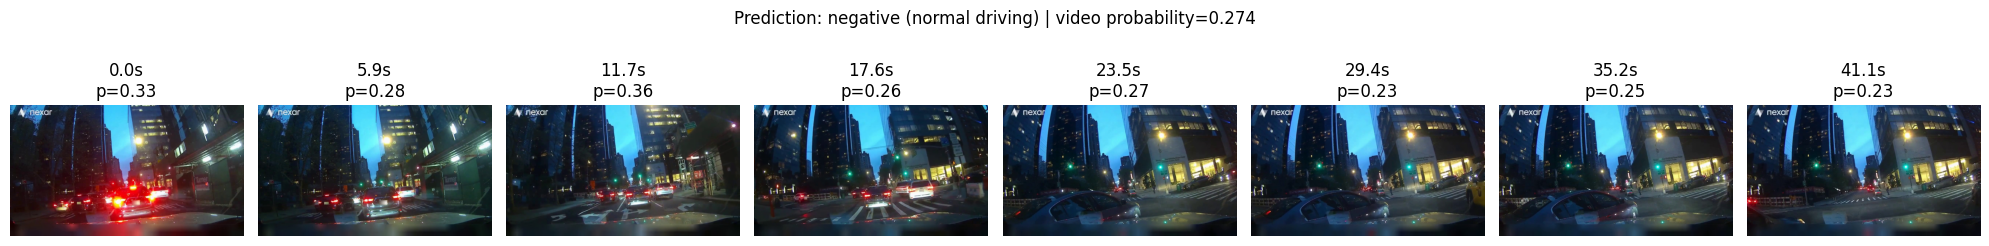

In [5]:
fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(20, 3))
for axis, frame, timestamp, probability in zip(
    axes, result['frames'], result['timestamps_seconds'], result['frame_probabilities']
):
    axis.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axis.set_title(f'{timestamp:.1f}s\np={probability:.2f}')
    axis.axis('off')
plt.suptitle(f"Prediction: {result['prediction_name']} | video probability={result['positive_probability']:.3f}")
plt.tight_layout()
plt.show()

## نکتهٔ گزارش

آستانهٔ فعلی از validation برای بیشینه‌کردن F1 انتخاب شده است. اگر سامانه باید هشدار اشتباه کمتری بدهد، می‌توان مقدار `decision_threshold` را به ۰.۵ یا مقدار بالاتر تغییر داد و trade-off آن را در گزارش توضیح داد.